# Evaluación 2 · Sección 4 — Visualización

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM · INF074H

**Integrantes:** Daniela Contreras · Emanuel Nicklichen

**Proyecto:** *Quedar fuera teniendo puntaje* — revisión del proceso de Admisión a la Educación Superior 2026.

Este notebook no repite gráficos ya mostrados en las Secciones 2 y 3 (boxplots de las pruebas, `VAC_1ER`, dependencia). Se eligieron 4 gráficos de tipos distintos, cada uno justificado por lo que aporta a la pregunta de investigación — no por completar una lista de tipos exigidos.

## Por qué estos cuatro, y no otros

| # | Tipo | Qué muestra | Por qué este y no otro |
|---|---|---|---|
| 1 | Histograma | Distribución del mejor puntaje ponderado logrado por los 27.492 que quedaron fuera, separando quienes tenían alternativa alcanzable de quienes no | Es la variable central de la Sección 3.7 (el resultado que responde la pregunta de investigación) y nunca se visualizó, solo se resumió en tablas |
| 2 | Dispersión (con overplotting) | `CLEC_MAX` vs. `MATE1_MAX` entre los 27.492, antes y después de tratar la transparencia | Es el caso real de mayor densidad de puntos del proyecto (27.048 pares); nunca se graficaron datos reales del proyecto en dispersión — el único scatter previo (Anscombe) era ilustrativo |
| 3 | Barras | % con alternativa alcanzable por dependencia | Es el hallazgo central de la Sección 3.7; una tabla de 6 números se lee de un vistazo como gráfico |
| 4 | Línea de tendencia | Puntaje promedio de `CLEC_MAX` y `MATE1_MAX` por decil de ingreso | Visualiza el patrón "casi monótono, con una caída en el decil 7" descrito en texto en la Sección 3.3, ahora comparando si se repite en ambas pruebas |

Se evitó deliberadamente repetir boxplots (ya usados 3 veces) o agregar un quinto gráfico "porque sí" — cada uno de estos cuatro reemplaza una tabla o una afirmación de texto que ya existía, haciéndola más fácil de leer, no agregando información nueva sin propósito.

## Carga

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw"

carpetas = {
    "Inscritos":       "PAES-2026-Inscritos-Puntajes",
    "Socioeconomico":  "PAES-2026-Socioeconomicos",
    "Postulantes":      "PAES-2026-Postulantes",
    "Matricula":        "PAES-2026-Matricula",
    "Oferta":           "PAES-2026-Oferta-Definitiva-Programas",
}
bases = {}
for nombre, carpeta in carpetas.items():
    archivo = list((RAW_DIR / carpeta).glob("*.csv"))[0]
    if nombre == "Oferta":
        bases[nombre] = pd.read_csv(archivo, sep=",", decimal=".")
    else:
        bases[nombre] = pd.read_csv(archivo, sep=";", decimal=",", low_memory=False)
A, B, C, D, O = bases["Inscritos"], bases["Socioeconomico"], bases["Postulantes"], bases["Matricula"], bases["Oferta"]

dep_map = {"1":"Corp. Municipal","2":"Municipal","3":"Part. Subvencionado",
           "4":"Part. Pagado","5":"Corp. Adm. Delegada","6":"SLEP"}
A["DEP_NOMBRE"] = A["DEPENDENCIA"].astype(str).str.strip().map(dep_map)

# Resultado de alternativa alcanzable, calculado en la Seccion 3.7 (se reconstruye
# aqui el resumen por estudiante para no repetir todo el desarrollo del calculo)
sel_alguna_vez = C.groupby("MRUN")["ESTADO_PREF"].apply(lambda x: x.isin([24,26]).any())
quedaron_fuera_mrun = sel_alguna_vez[~sel_alguna_vez].index
print(f"Quedaron fuera: {len(quedaron_fuera_mrun)}")

Quedaron fuera: 27492


## 4.1 Histograma: mejor puntaje logrado, según si tenían alternativa alcanzable

In [2]:
# Recalculamos el resultado de la Seccion 3.7: mejor puntaje ponderado logrado
# por cada estudiante entre sus oportunidades de su area de interes, y si supero
# el corte de alguna (mismo codigo, resumido para no repetir 6 celdas completas)
C_con_carrera = C.merge(O[["COD_CARRERA","CARRERA"]], left_on="COD_CARRERA_PREF", right_on="COD_CARRERA", how="left")
interes = C_con_carrera[C_con_carrera["MRUN"].isin(quedaron_fuera_mrun)][["MRUN","CARRERA"]].drop_duplicates()

matriculados = D.groupby("CODIGO_CARRERA").size().rename("matriculados")
seleccionados = C[(C["TIPO_PREF"]=="REGULAR") & (C["ESTADO_PREF"]==24)].copy()
seleccionados["ptje_real"] = pd.to_numeric(seleccionados["PTJE_PREF"].str.replace(",", "."), errors="coerce")
corte = seleccionados.groupby("COD_CARRERA_PREF")["ptje_real"].min().rename("corte_real")
oferta = O.merge(matriculados, left_on="COD_CARRERA", right_index=True, how="left")
oferta = oferta.merge(corte, left_on="COD_CARRERA", right_index=True, how="left")
oferta["matriculados"] = oferta["matriculados"].fillna(0)
oferta["cupos_sin_llenar"] = (oferta["VAC_1ER"] - oferta["matriculados"]).clip(lower=0)
candidatos = oferta[(oferta["cupos_sin_llenar"]>0) & (oferta["corte_real"].notna())]

oportunidades = interes.merge(candidatos, on="CARRERA", how="inner")
oportunidades = oportunidades.merge(
    A[["MRUN","PTJE_NEM","PTJE_RANKING","CLEC_MAX","MATE1_MAX","MATE2_MAX","HCSOC_MAX","CIEN_MAX"]],
    on="MRUN", how="left")

w_hsco = oportunidades["HSCO"].fillna(0); w_cien = oportunidades["CIEN"].fillna(0)
score_hc = np.select([(w_hsco>0)&(w_cien>0), (w_hsco>0)&(w_cien==0), (w_cien>0)&(w_hsco==0)],
    [oportunidades[["HCSOC_MAX","CIEN_MAX"]].max(axis=1), oportunidades["HCSOC_MAX"], oportunidades["CIEN_MAX"]], default=0)
peso_hc = np.maximum(w_hsco, w_cien)
es_ext = (oportunidades["PTJE_NEM"]==0) | (oportunidades["PTJE_RANKING"]==0)
peso_clec, peso_m1, peso_m2 = oportunidades["CLEC"].fillna(0), oportunidades["M1"].fillna(0), oportunidades["M2"].fillna(0)
resto = peso_clec + peso_m1 + peso_hc + peso_m2
factor = np.where(es_ext & (resto>0), 100/resto, 1)
numerador = (oportunidades["PTJE_NEM"]*np.where(es_ext,0,oportunidades["NEM"].fillna(0)) +
             oportunidades["PTJE_RANKING"]*np.where(es_ext,0,oportunidades["RANKING"].fillna(0)) +
             oportunidades["CLEC_MAX"]*np.where(es_ext, peso_clec*factor, peso_clec) +
             oportunidades["MATE1_MAX"]*np.where(es_ext, peso_m1*factor, peso_m1) +
             score_hc*np.where(es_ext, peso_hc*factor, peso_hc) +
             oportunidades["MATE2_MAX"]*np.where(es_ext, peso_m2*factor, peso_m2))
oportunidades["puntaje_calculado"] = numerador/100
oportunidades["supera_corte"] = oportunidades["puntaje_calculado"] > oportunidades["corte_real"]

mejor_puntaje = oportunidades.groupby("MRUN")["puntaje_calculado"].max().rename("mejor_puntaje")
tiene_alt = oportunidades.groupby("MRUN")["supera_corte"].any().rename("tiene_alternativa")
alternativa = pd.DataFrame({"MRUN": quedaron_fuera_mrun}).merge(tiene_alt, on="MRUN", how="left").merge(mejor_puntaje, on="MRUN", how="left")
alternativa["tiene_alternativa"] = alternativa["tiene_alternativa"].fillna(False).astype(bool)

print(alternativa.groupby("tiene_alternativa")["mejor_puntaje"].describe().round(1))

                     count   mean    std    min    25%    50%    75%    max
tiene_alternativa                                                          
False               4405.0  713.4  148.2    0.0  631.4  750.0  831.6  911.2
True               20336.0  619.7   96.2  379.9  550.2  609.4  678.5  958.2


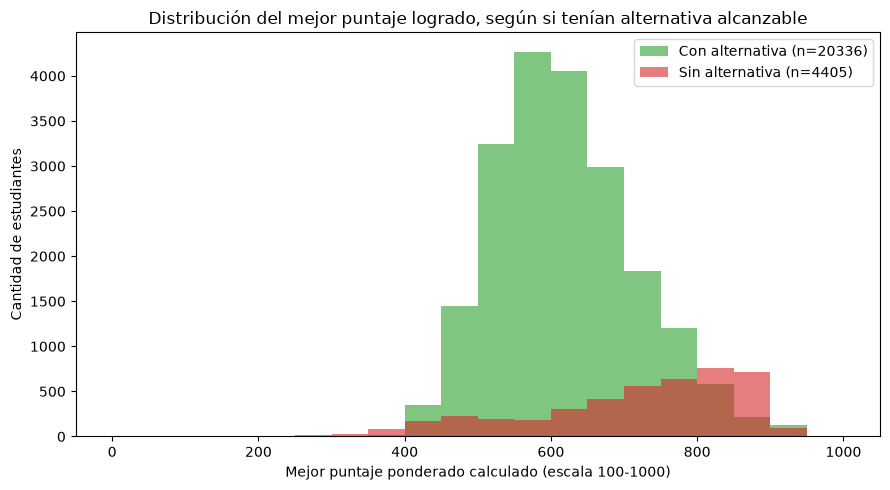

In [3]:
# Grafico 1: histograma de mejor_puntaje, separado por resultado
fig, ax = plt.subplots(figsize=(9, 5))
con = alternativa.loc[alternativa["tiene_alternativa"], "mejor_puntaje"].dropna()
sin = alternativa.loc[~alternativa["tiene_alternativa"], "mejor_puntaje"].dropna()
bins = range(0, 1050, 50)

ax.hist(con, bins=bins, alpha=0.6, color="#2ca02c", label=f"Con alternativa (n={len(con)})")
ax.hist(sin, bins=bins, alpha=0.6, color="#d62728", label=f"Sin alternativa (n={len(sin)})")
ax.set_xlabel("Mejor puntaje ponderado calculado (escala 100-1000)")
ax.set_ylabel("Cantidad de estudiantes")
ax.set_title("Distribución del mejor puntaje logrado, según si tenían alternativa alcanzable")
ax.legend()
plt.tight_layout()
plt.show()

**El grupo sin alternativa no es un grupo de bajo puntaje — es lo contrario.** Su mejor puntaje promedio (713,4) es más alto que el de quienes sí encontraron alternativa (619,7). Esto es coherente con el hallazgo de la Sección 3.7: no es que les faltara puntaje, es que apuntaron a programas tan selectivos que ni un puntaje alto alcanzó — el problema no es de capacidad, es de qué tan angosto es el margen de sustitución en las carreras que persiguen.

## 4.2 Dispersión: CLEC_MAX vs. MATE1_MAX, con tratamiento de overplotting

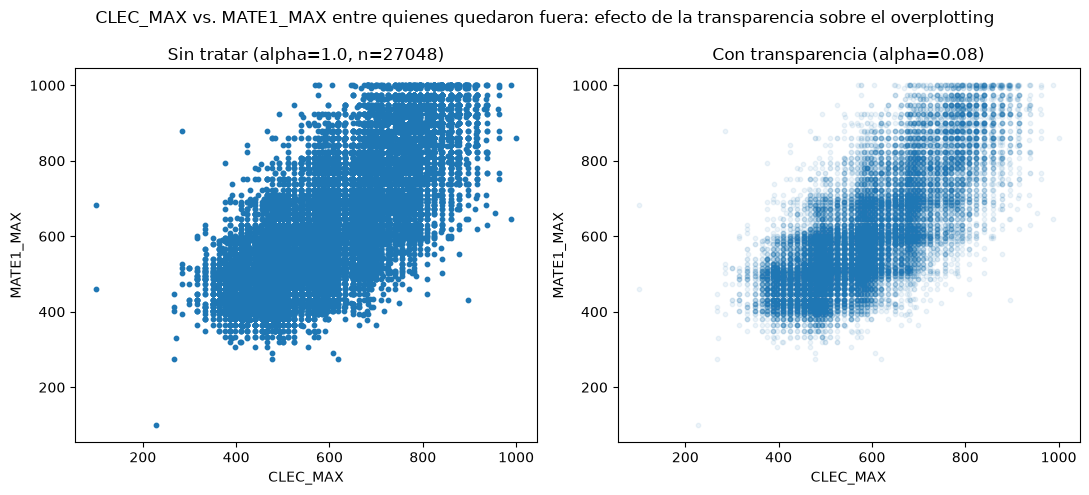

In [4]:
quedaron_fuera = A[A["MRUN"].isin(quedaron_fuera_mrun)]
sub = quedaron_fuera[(quedaron_fuera["CLEC_MAX"]>0) & (quedaron_fuera["MATE1_MAX"]>0)]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Panel izquierdo: sin tratar -- con 27 mil puntos superpuestos, se ve una mancha
axes[0].scatter(sub["CLEC_MAX"], sub["MATE1_MAX"], s=10, alpha=1.0)
axes[0].set_title(f"Sin tratar (alpha=1.0, n={len(sub)})")
axes[0].set_xlabel("CLEC_MAX"); axes[0].set_ylabel("MATE1_MAX")

# Panel derecho: alpha bajo revela donde se concentra realmente la densidad
axes[1].scatter(sub["CLEC_MAX"], sub["MATE1_MAX"], s=10, alpha=0.08)
axes[1].set_title("Con transparencia (alpha=0.08)")
axes[1].set_xlabel("CLEC_MAX"); axes[1].set_ylabel("MATE1_MAX")

plt.suptitle("CLEC_MAX vs. MATE1_MAX entre quienes quedaron fuera: efecto de la transparencia sobre el overplotting")
plt.tight_layout()
plt.show()

En el panel izquierdo no se distingue dónde se concentra realmente la mayoría de los estudiantes — todo se ve igual de denso. Con transparencia (derecha) aparece con claridad una zona de mayor concentración entre 500-700 puntos en ambas pruebas, y se nota que la relación es más dispersa en los extremos bajos que en el centro. No se usó `hexbin` porque, con `alpha` fue suficiente para revelar el patrón sin perder los puntos individuales de los extremos, que también son informativos (no son ruido, son estudiantes reales).

## 4.3 Barras: alternativa alcanzable por dependencia

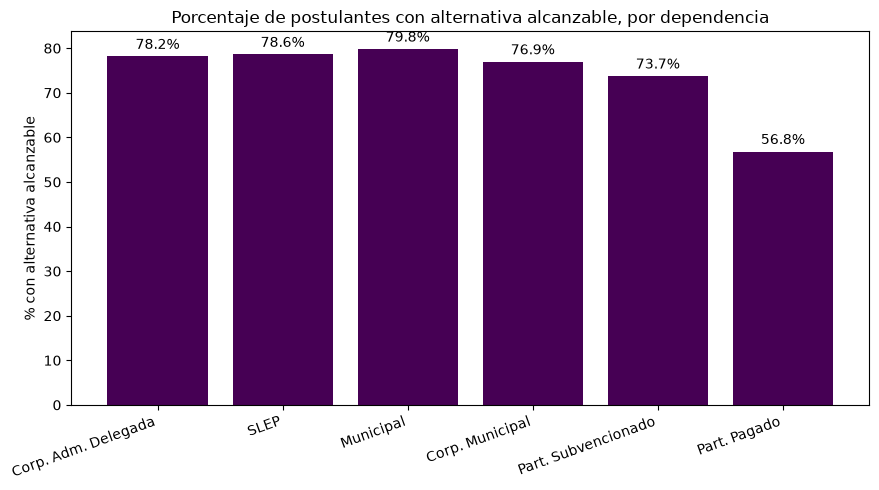

In [7]:
# Grafico 3: mismo crosstab de la Seccion 3.7, ahora como barras
tabla = pd.crosstab(A.merge(alternativa, on="MRUN")["DEP_NOMBRE"],
                     A.merge(alternativa, on="MRUN")["tiene_alternativa"], normalize="index") * 100
orden = ["Corp. Adm. Delegada", "SLEP", "Municipal", "Corp. Municipal", "Part. Subvencionado", "Part. Pagado"]
tabla = tabla.reindex(orden)

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(tabla.index, tabla[True], color="#460054")
ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Porcentaje de postulantes con alternativa alcanzable, por dependencia")
ax.set_xticks(range(len(tabla.index)))
ax.set_xticklabels(tabla.index, rotation=20, ha="right")
ax.bar_label(barras, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

Cinco de las seis dependencias se agrupan entre 73,7% y 79,8%; Particular Pagado se despega claramente hacia abajo (56,8%) — el mismo patrón contrario a la hipótesis que se documentó en la Sección 3.7, ahora visible de un vistazo.

## 4.4 Línea de tendencia: puntaje promedio por decil de ingreso

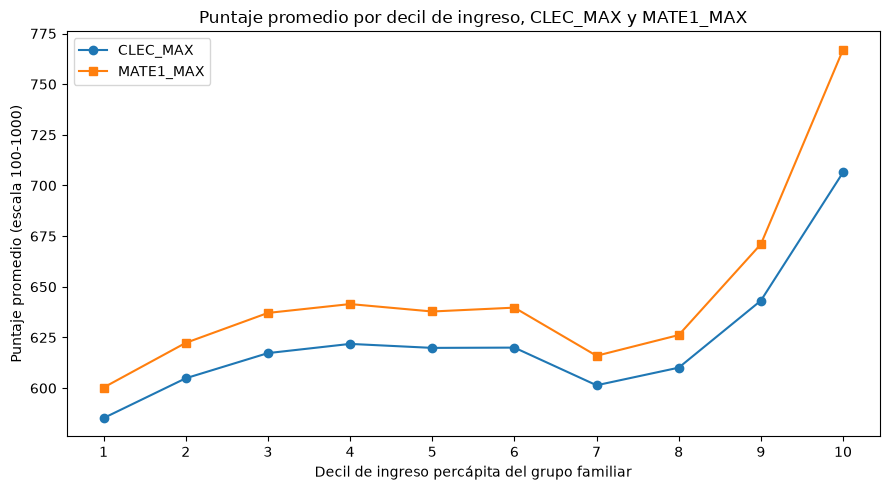

In [6]:
# Grafico 4: promedio por decil, misma logica de 3.3 pero ahora con MATE1_MAX tambien
AB = A.merge(B[["MRUN","INGRESO_PERCAPITA_GRUPO_FA"]], on="MRUN", how="left")
AB_valido = AB[AB["INGRESO_PERCAPITA_GRUPO_FA"] != 99]  # excluye el codigo disfrazado (Seccion 1)

clec_decil = AB_valido[AB_valido["CLEC_MAX"]>0].groupby("INGRESO_PERCAPITA_GRUPO_FA")["CLEC_MAX"].mean()
mate1_decil = AB_valido[AB_valido["MATE1_MAX"]>0].groupby("INGRESO_PERCAPITA_GRUPO_FA")["MATE1_MAX"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(clec_decil.index, clec_decil.values, marker="o", label="CLEC_MAX")
ax.plot(mate1_decil.index, mate1_decil.values, marker="s", label="MATE1_MAX")
ax.set_xlabel("Decil de ingreso percápita del grupo familiar")
ax.set_ylabel("Puntaje promedio (escala 100-1000)")
ax.set_title("Puntaje promedio por decil de ingreso, CLEC_MAX y MATE1_MAX")
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.show()

El mismo quiebre en el decil 7 aparece en **ambas** pruebas, no solo en `CLEC_MAX` — descarta que fuera una particularidad de una sola variable. El salto grande entre el decil 9 y el 10 también se repite en las dos, y es más pronunciado en `MATE1_MAX` (de 671 a 767) que en `CLEC_MAX` (de 643 a 706).

## Uso de Inteligencia Artificial

Se utilizó **Claude (Anthropic)** como asistente para la generación de las visualizaciones de este notebook y la redacción de las interpretaciones. La selección de qué graficar y por qué, y la verificación final de cada lectura, son del equipo; todas las cifras son reproducibles sobre las bases públicas declaradas.